# Task 1.a: Write the hypotheses explicitly

1.Null ($H_{0}$): Popularity rating has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): A higher popularity rating increases the chance of winning an award.

2.Null ($H_{0}$): Explicitness of a song has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): Explicit songs are less likely to win an award.

3.Null ($H_{0}$): Tempo has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): Songs with a higher tempo are more likely to win an award.

# Task 1.b: Choose and justify approporiate test

**1.Regression Coefficient Test**
<br>
**Regression Coefficient Test** are used to determine if a **predictor variable** has a **statistically significant relationship** with a **dependent variable**. Since **Popularity Rating** is a **Continuous Variable** it will be our **predictor variable** and **Grammy Winner**, a **Categorical Variable** will be our **dependent variable**. This will test whether popularity significantly predicts the probability of winning.

**2.Chi-Square Test**
<br>
**Chi-Square Test** are used on **categorical data** to determine if there is a **significant relationship** between **two variables**, or if your observed data **matches** an **expected distribution**. We will compare two categorical variables in **Explicitness** and **Grammy Winner** to see whether the two have a relationship.

**3.Regression Coefficient Test**
<br>
**Regression Coefficient Test** are used to determine if a **predictor variable** has a **statistically significant relationship** with a **dependent variable**. Since **Tempo** is a **Continuous Variable** it will be our **predictor variable** and **Grammy Winner**, a **Categorical Variable** will be our **dependent variable**. This will test whether tempo significantly predicts the probability of winning.

# Task 1.c: Test Statistic, P-value, and Comparison

In [1]:
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2_contingency
df = pd.read_csv("newdata (2).csv")

# Regression Coefficient Test of Popularity & Winner:

In [2]:
x = sm.add_constant(df['popularity'])
y = df['winner']

model_popularity = sm.OLS(y, x).fit()

z_stat = model_popularity.tvalues['popularity']
p_value = model_popularity.pvalues['popularity']
alpha = 0.05

print("Regression Coefficient Test of Popularity & Winner: ")
print(f"Test Statistic (z): {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

Regression Coefficient Test of Popularity & Winner: 
Test Statistic (z): 13.018
p-value: 0.0000
Significance Level (α): 0.05


**Since the p-value of 0.0000 is less than our significance level of 0.05 we reject the null hypothesis of "Popularity rating has no effect on the chance of winning an award."**
<br>
**Popularity significantly predicts the chance of winning an award. In our dataset, songs with higher popularity ratings are much more likely to win awards.**

# Chi-Square test of Explictness & Winner:

In [3]:
contingency = pd.crosstab(df['explicit'], df['winner'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
alpha = 0.05

print("Chi-Square Test of Explictness & Winner:")
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

Chi-Square Test of Explictness & Winner:
Chi-Square Statistic: 1.865
p-value: 0.1720
Significance Level (α): 0.05


**Since the p-value of 0.1720 is greater than our significance level of 0.05 we fail to reject the null hypothesis of "Explicitness of a song has no effect on the chance of winning an award."**
<br>
**There is no significant relationship between explicitness and award outcome. In our dataset, explicit songs are neither more or less likely to win awards.**

# Regression Coefficient Test of Tempo & Winner:

In [4]:
x = sm.add_constant(df['tempo'])
y = df['winner']

model_popularity = sm.OLS(y, x).fit()

z_stat = model_popularity.tvalues['tempo']
p_value = model_popularity.pvalues['tempo']
alpha = 0.05

print("Regression Coefficient Test of Tempo & Winner: ")
print(f"Test Statistic (z): {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

Regression Coefficient Test of Tempo & Winner: 
Test Statistic (z): -0.484
p-value: 0.6287
Significance Level (α): 0.05


**Since the p-value of 0.6287 is greater than our significance level of 0.05 we fail to reject the null hypothesis of "Tempo has no effect on the chance of winning an award."**
<br>
**Tempo does not significantly affect the chance of winning an award. Faster or slower songs have similar likelihoods of winning.**

# Task 2.a Building and ML model
- We chose to use the **classification** problem type (Winner vs Not Winner)
- The **binary** aspect of Winner (1) vs Not Winner (0) make it easier to visualize and graph

Non-winners (0): 111455 (97.22%)
Winners (1): 3191 (2.78%)

Class Imbalance Ratio: 34.93:1


/var/folders/jw/5j192x3n2yddj2wxvmd0_h3w0000gn/T/ipykernel_76094/1772207830.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Non-winners (0): {winner_counts[0]} ({winner_counts[0]/len(df)*100:.2f}%)")
/var/folders/jw/5j192x3n2yddj2wxvmd0_h3w0000gn/T/ipykernel_76094/1772207830.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Winners (1): {winner_counts[1]} ({winner_counts[1]/len(df)*100:.2f}%)")
/var/folders/jw/5j192x3n2yddj2wxvmd0_h3w0000gn/T/ipykernel_76094/1772207830.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always

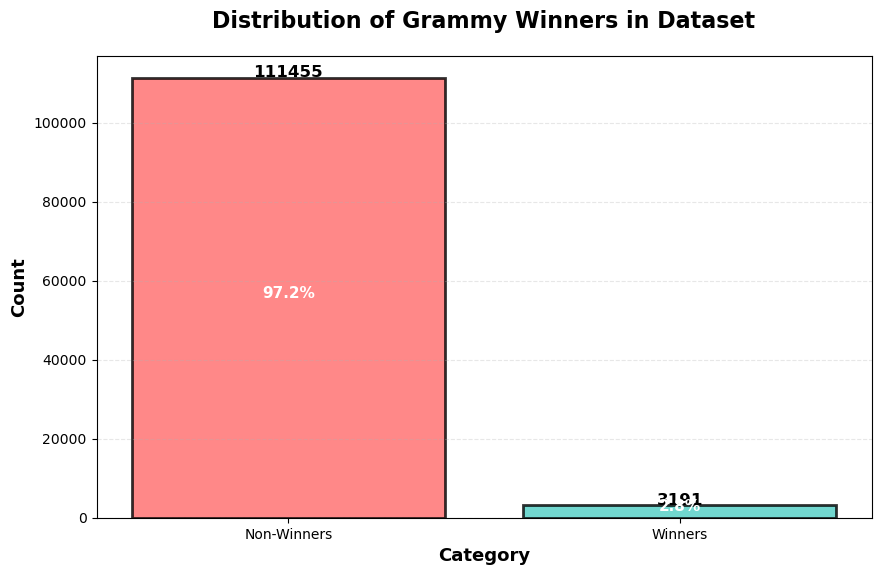

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

winner_counts = df['winner'].value_counts()
print(f"Non-winners (0): {winner_counts[0]} ({winner_counts[0]/len(df)*100:.2f}%)")
print(f"Winners (1): {winner_counts[1]} ({winner_counts[1]/len(df)*100:.2f}%)")
print(f"\nClass Imbalance Ratio: {winner_counts[0]/winner_counts[1]:.2f}:1")

# Visualize target distribution
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(['Non-Winners', 'Winners'], winner_counts.values, color=colors, 
               edgecolor='black', linewidth=2, alpha=0.8)
plt.title('Distribution of Grammy Winners in Dataset', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xlabel('Category', fontsize=13, fontweight='bold')

# Add count labels on bars
for i, v in enumerate(winner_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=12)
    plt.text(i, v/2, f'{v/len(df)*100:.1f}%', ha='center', 
             fontweight='bold', fontsize=11, color='white')

plt.grid(axis='y', alpha=0.3, linestyle='--')


Based on the graph, it can be seen that 97 percent of songs do not win the 

# Task 2.b Feature Importance & Selection
- The approach that we chose to take with choosing feature importance was creating a correlation matrix (heat map) and taking note of how strongly (in either direction) each feature correlated with **award**
- The derived bar graph represents each feature's correlating relationship with the target variable.  

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("newdata (2).csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

label_encoder = LabelEncoder()
df['artists'] = label_encoder.fit_transform(df['artists'])
df['track_name'] = label_encoder.fit_transform(df['track_name'])
df['track_genre'] = label_encoder.fit_transform(df['track_genre'])

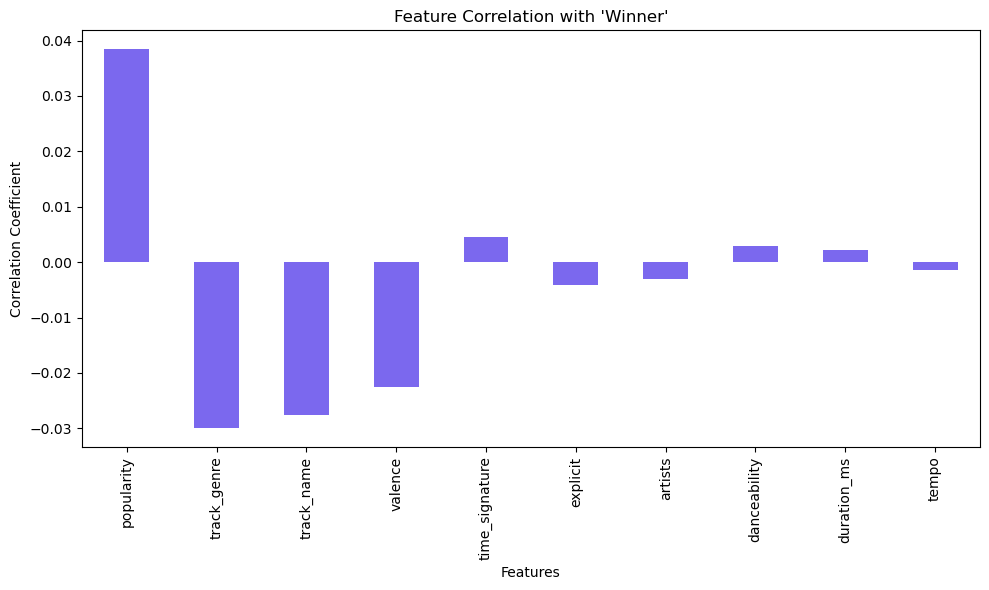

In [7]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Get correlations with the target variable 'winner'
corr_with_winner = corr_matrix['winner'].drop('winner')

# Sort by absolute correlation value
corr_with_winner = corr_with_winner.sort_values(key=abs, ascending=False)
corr_with_winner

plt.figure(figsize=(10, 6))
corr_with_winner.plot(kind='bar', color='mediumslateblue')
plt.title("Feature Correlation with 'Winner'")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


Based on our bar chart, we can see that most features have weak linear relationships with whether a song wins an award. However, we'll keep numeric variables such as popularity, tempo, valence and genre since due to their numeric nature, they can still contribute predictive power. 

# 2.c Baseline Model -- Linear Regression

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score

X = df[['popularity', 'danceability', 'valence', 'tempo', 'track_genre']]
y = df['winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
degrees = [1,2,3,5]
results = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_poly)
    
    # Regression metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Convert to classification (0.5 threshold)
    y_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_class)
    prec = precision_score(y_test, y_class, zero_division=0)
    rec = recall_score(y_test, y_class, zero_division=0)
    
    results.append((d, r2, rmse, acc, prec, rec))

results_df = pd.DataFrame(results, columns=['Degree', 'R2', 'RMSE', 'Accuracy', 'Precision', 'Recall'])
print(results_df)

   Degree        R2      RMSE  Accuracy  Precision  Recall
0       1  0.003370  0.165930  0.971566        0.0     0.0
1       2  0.010555  0.165331  0.971566        0.0     0.0
2       3  0.011625  0.165241  0.971566        0.0     0.0
3       5  0.012617  0.165158  0.971566        0.0     0.0


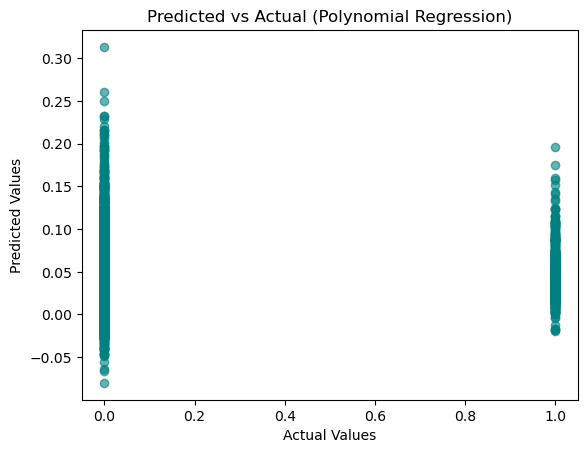

In [10]:
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Polynomial Regression)")
plt.show()

We trained polynomial regression models with degrees 1, 2, 3, and 5 to predict whether a song wins an award based on its features. As degree increased, R² improved and RMSE decreased, suggesting slightly better model fit. **Degree 2** provided the best trade-off, because it offered noticeably better performance than degree 1 without excessive complexity.  
Because our target variable (winner) is binary, the linear regression model’s predictions cluster near 0 and 1, resulting in a vertically separated scatter plot, and so the actual visualization of predicted vs actual values isn't as informative as desired.

# Task 2.d Additonal Models Exploration
We split up the additonal models between group members as such
- Support Vector Machine (SVM) - Christian Cureton
- Random Forest Classifier - Hiwete Teshale
- Decision Tree Classifier - Chase Solano
- Logistic Regression - Isaiah Hames

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## Support Vector Machine (SVM) ##

In [12]:
#Create the SVM model
svm_model = LinearSVC(class_weight='balanced', random_state=42)

#Train the SVM model on the data
svm_model.fit(X_train, y_train

#Utilize the trained model to make predictions on the set
y_pred_svm = svm_model.predict(X_test)

#Calculate the performance metrics             
acc_svm = accuracy_score(y_test, y_pred_svm)           
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)

print("SVM Results: ")
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")


SVM Results: 
Accuracy:  0.5612
Precision: 0.0373
Recall:    0.5813


The SVM model attained an accuracy of 0.5612, meaning it was able to classify about 56% of the test samples. There was a fairly moderate recall of 0.5813, which tells us the model was able to identify more than half of the positive cases. The precision of the model was low, with a 0.0373, indicating that the majority of the predictions made that were positive were incorrect. Due to the disparity between the recall and the precision, we can conclude that the model is over-predicting the positive class and cannot reliably distinguish the winners from the non-winners. Therefore the SVM model is not reliable for this classification

## Random Forest Classifier ##

In [13]:
#Create the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42)

#Train the  Random Forest Classifier model on the data
rf_model.fit(X_train, y_train)

#Utilize the trained model to make predictions on the set
y_pred_rf = rf_model.predict(X_test)

#Calculate the performance metrics             
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Classifier Results: ")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")

Random Forest Classifier Results: 
Accuracy:  0.9867
Precision: 1.0000
Recall:    0.5337


The Random Forest Classifier was able to reach a high accuracy of 0.9867, meaning it classified about 99% of the samples in the set. The model attained a perfect precision of 1, meaning every instance predicted as a winner was correct. The recall overall, though, was moderate with 0.5337, meaning it was able to successfully identify just about half of the true winners, while missing the rest. Therefore, the Random Forest model is reliable for confirming the winner, but it still has some issues detecting the true winner cases without sacrificing some of its precision.

## Decision Tree Classifier ##

In [14]:
#Create the Decision Tree Classifier model
tree_model = DecisionTreeClassifier(max_depth=None, class_weight='balanced', random_state=42)

#Train the Decision Tree Classifier model on the data
tree_model.fit(X_train, y_train)

#Utilize the trained model to make predictions on the set
y_pred_tree = tree_model.predict(X_test)

#Calculate the performance metrics             
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree, zero_division=0)
rec_tree = recall_score(y_test, y_pred_tree, zero_division=0)

print("Decision Tree Results: ")
print(f"Accuracy:  {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall:    {rec_tree:.4f}")

Decision Tree Results: 
Accuracy:  0.9727
Precision: 0.5183
Recall:    0.5874


The Decision Tree Classifier reached a high accuracy of 0.9727, indicating that the model classified about 97% of the test samples. There was a moderate precision of 0.5183, which shows that half of the cases that were predicted as winners were correct. The recall of 0.5874 tells us that the model successfully identified nearly 59% of the true winners in the dataset. The Decision tree classifier shares a good balance between precision and recall, thus meaning it does not over-predict the positive class while also not missing as many winners as some of the other models. Therefore, the Decision Tree is very effective at detecting winners, but there could be some minor improvments to its accuracy.

## Logistic Regression ##

In [15]:
#Create the Logistic Regression model
log_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

#Train the Logistic Regression model on the data
log_model.fit(X_train, y_train)

#Utilize the trained model to make predictions on the set
y_pred_log = log_model.predict(X_test)

#Calculate the performance metrics
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log, zero_division=0)
rec_log = recall_score(y_test, y_pred_log, zero_division=0)

print("Logistic Regression Results: ")
print(f"Accuracy:  {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall:    {rec_log:.4f}")

Logistic Regression Results: 
Accuracy:  0.5614
Precision: 0.0373
Recall:    0.5813


The Logistic Regression model reached an accuracy of 0.5614, meaning it only correctly classified about 56% of the samples. The model had a very low precision of 0.0373, indicating only about 3.7% of the songs predicted as winners were actual winners. The model's recall was moderate with 0.5813, which tells us it successfully identified over half of the true winners within the dataset. While the Logistic Regression model is able to catch some of the actual winners, it struggles altogether to predict them accurately. Overall, the model over-predicts the positive class, thus making this model unreliable in this scenario.

# Task 2.e Model Comparison

In [17]:
data = {
    "Model": [
        "Polynomial Regression",
        "Logistic Regression",
        "Support Vector Machine (SVM)",
        "Decision Tree Classifier",
        "Random Forest Classifier"
    ],
    "Accuracy": [0.9716, 0.5614, 0.5612, 0.9727, 0.9867],
    "Precision": [0.0000, 0.0373, 0.0373, 0.5183, 1.0000],
    "Recall": [0.0000, 0.5813, 0.5813, 0.5874, 0.5337]
}

results_table = pd.DataFrame(data)
results_table

,Model,Accuracy,Precision,Recall
0,Polynomial Regression,0.9716,0.0000,0.0000
1,Logistic Regression,0.5614,0.0373,0.5813
2,Support Vector Machine (SVM),0.5612,0.0373,0.5813
3,Decision Tree Classifier,0.9727,0.5183,0.5874
4,Random Forest Classifier,0.9867,1.0000,0.5337


Taking a look at all the models' performances, the best-performing model is the Random Forest Classifier. This model was able to achieve the highest accuracy of 0.9867 and the perfect precision of 1, thus meaning every song it predicted as a winner was an actual winner. The only main drawback of the model is that it does not capture all the possible winners due to the recall of 0.5337, it only identifies more than half of them. Therefore, the Random Forest model is the best-performing model out of all the models explored.